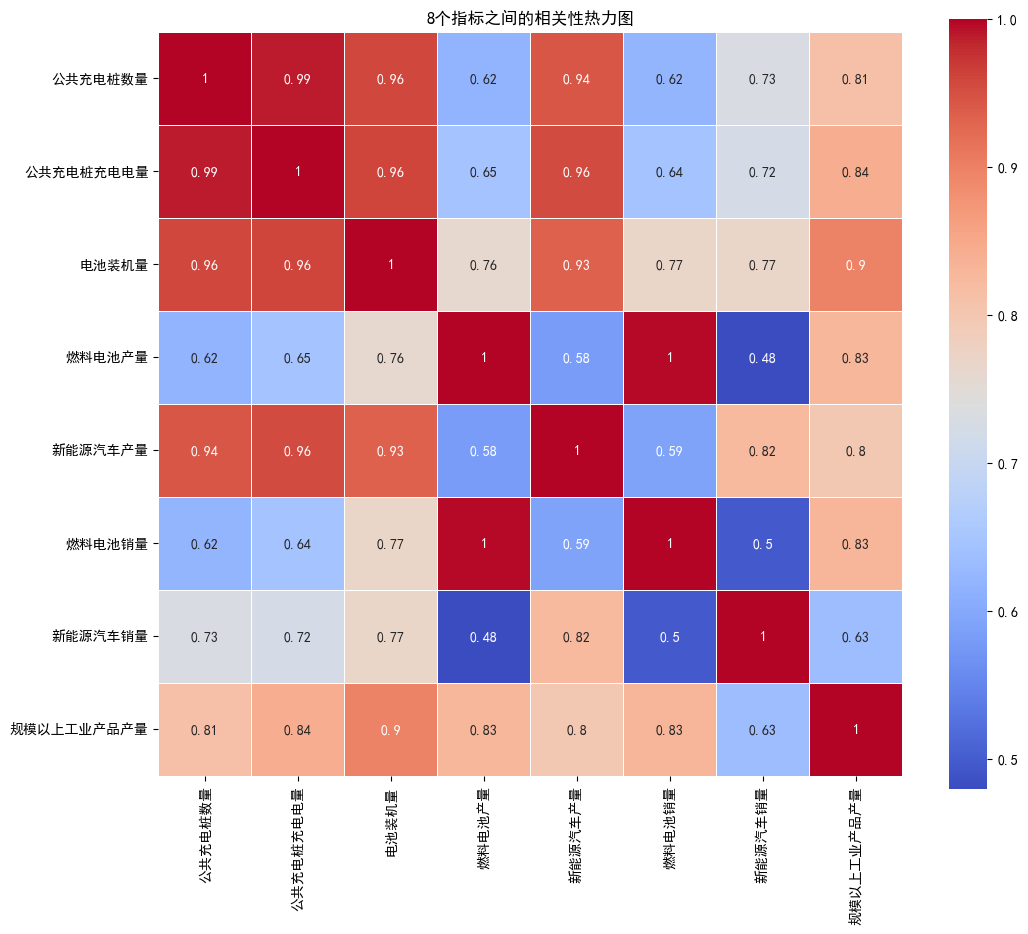

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

file_path = '数据描述量.xlsx'
df = pd.read_excel(file_path)

columns = ['公共充电桩数量', '公共充电桩充电电量', '电池装机量', '燃料电池产量', 
           '新能源汽车产量', '燃料电池销量', '新能源汽车销量', '规模以上工业产品产量']

df_selected = df[columns]

# 计算相关性矩阵
corr_matrix = df_selected.corr()

# 绘制热力图
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, square=True)
plt.title('8个指标之间的相关性热力图')
plt.show()

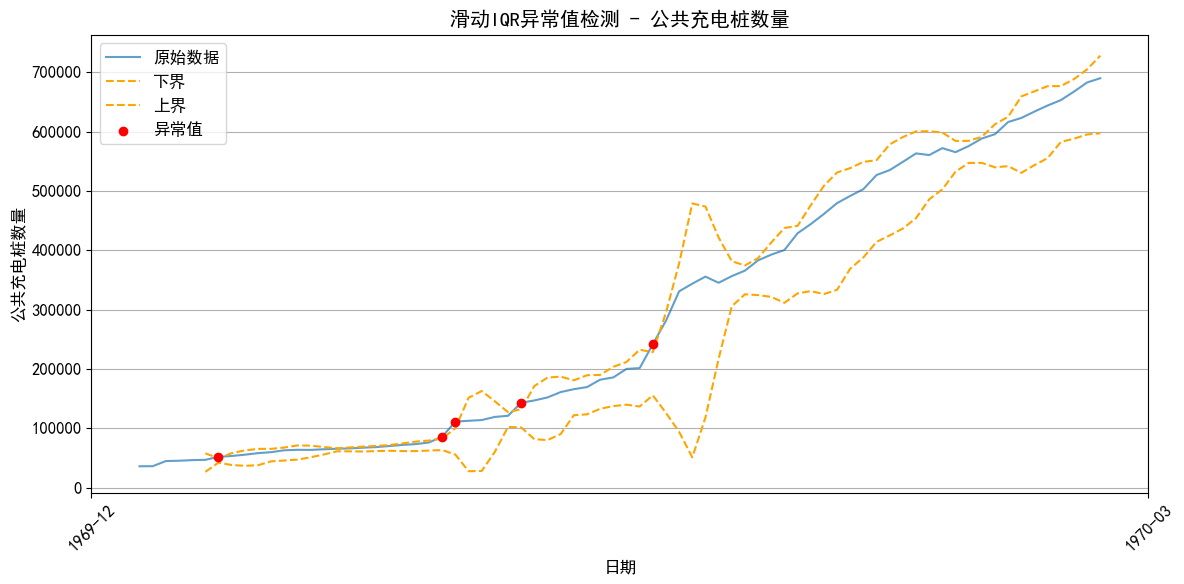

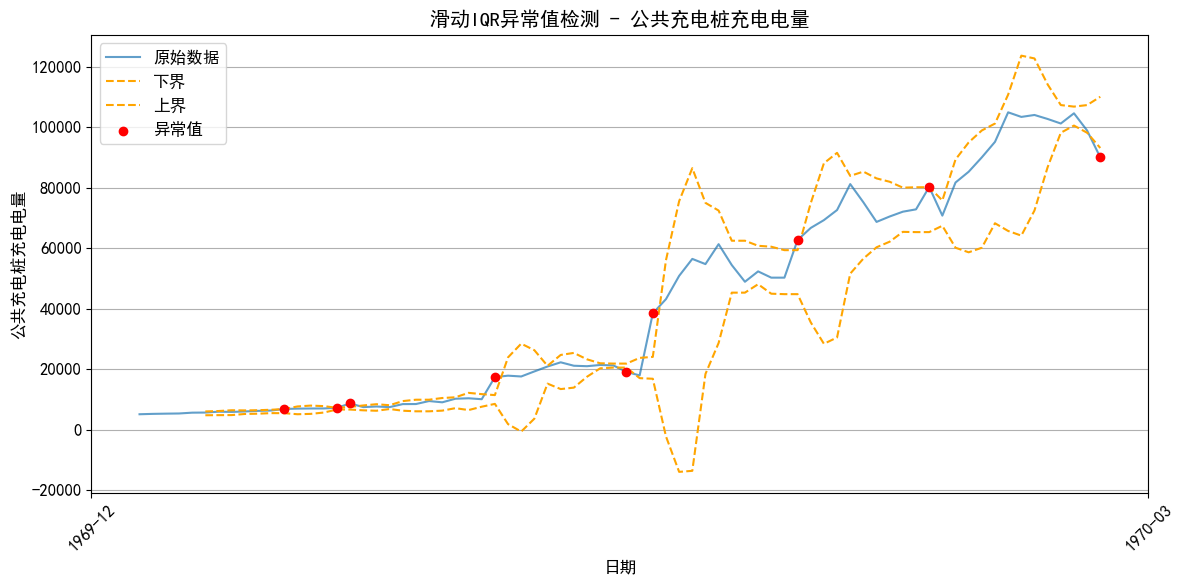

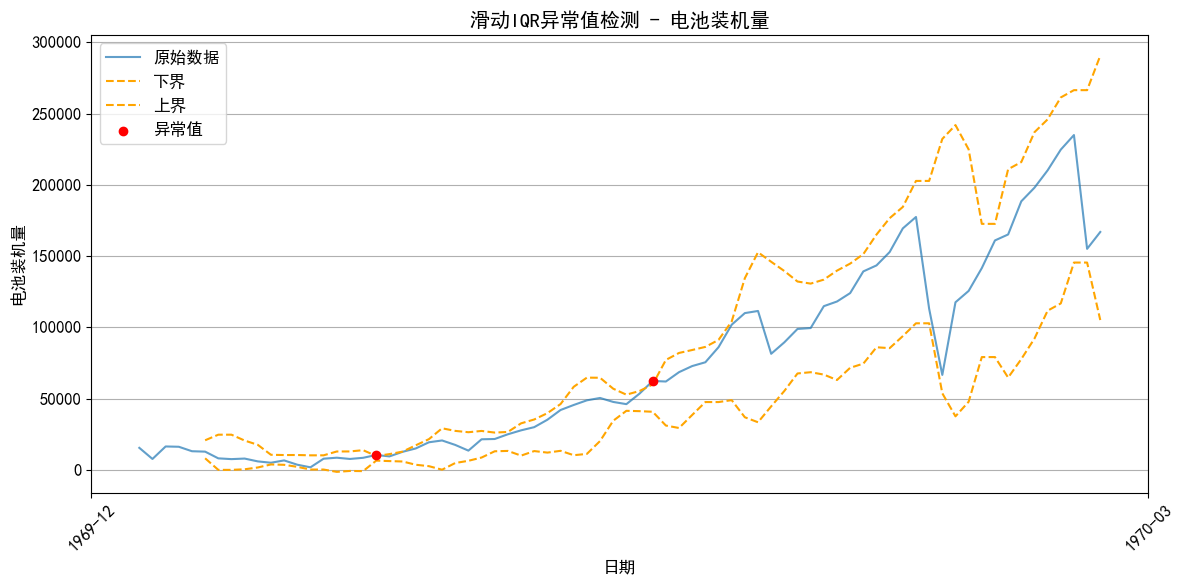

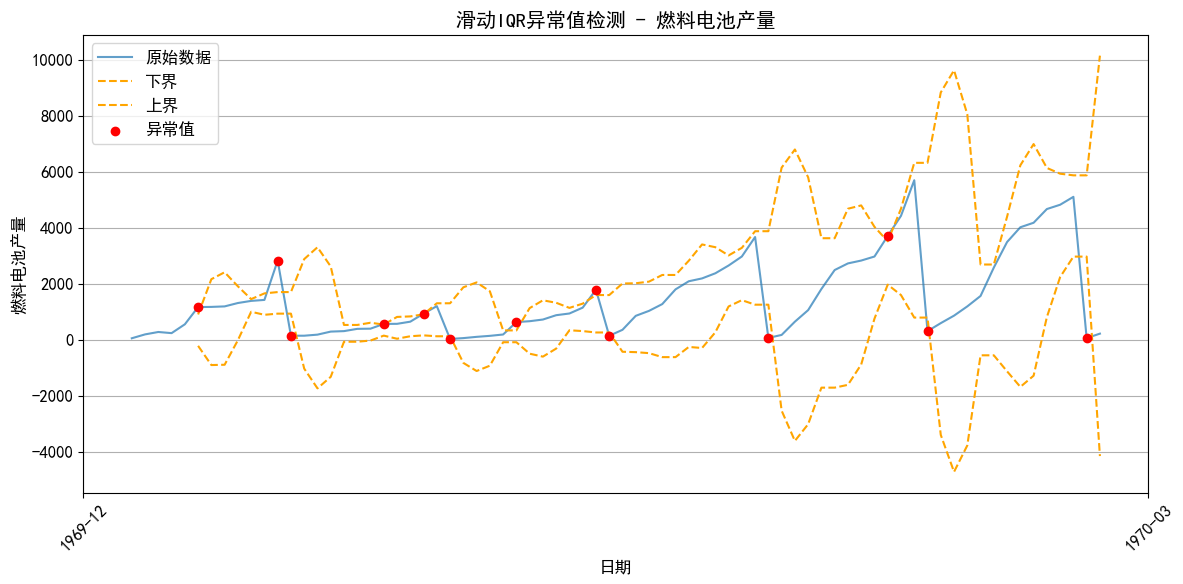

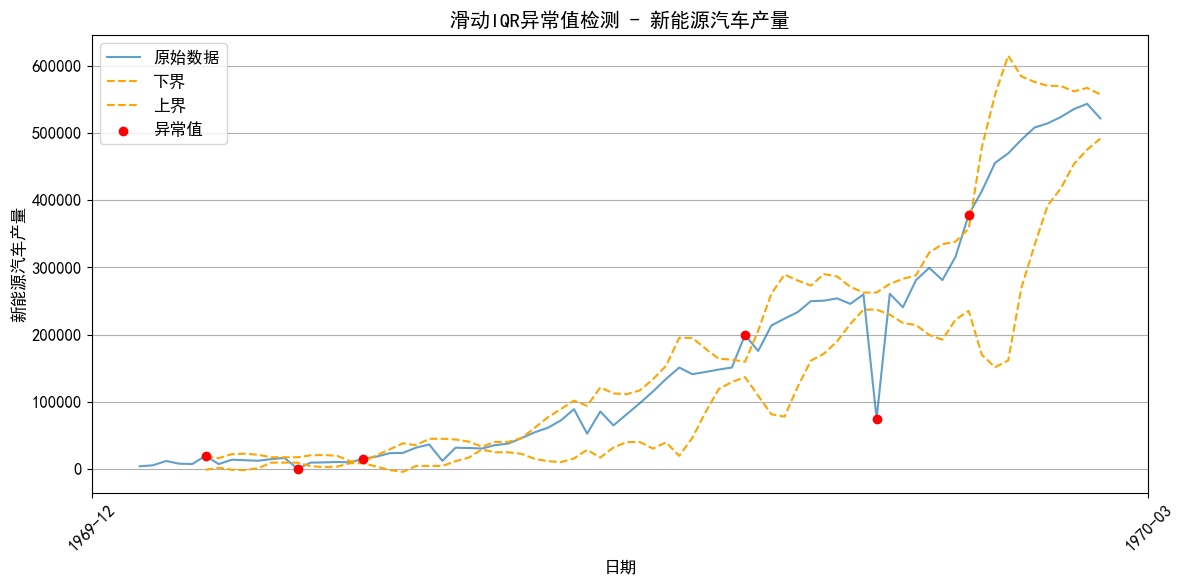

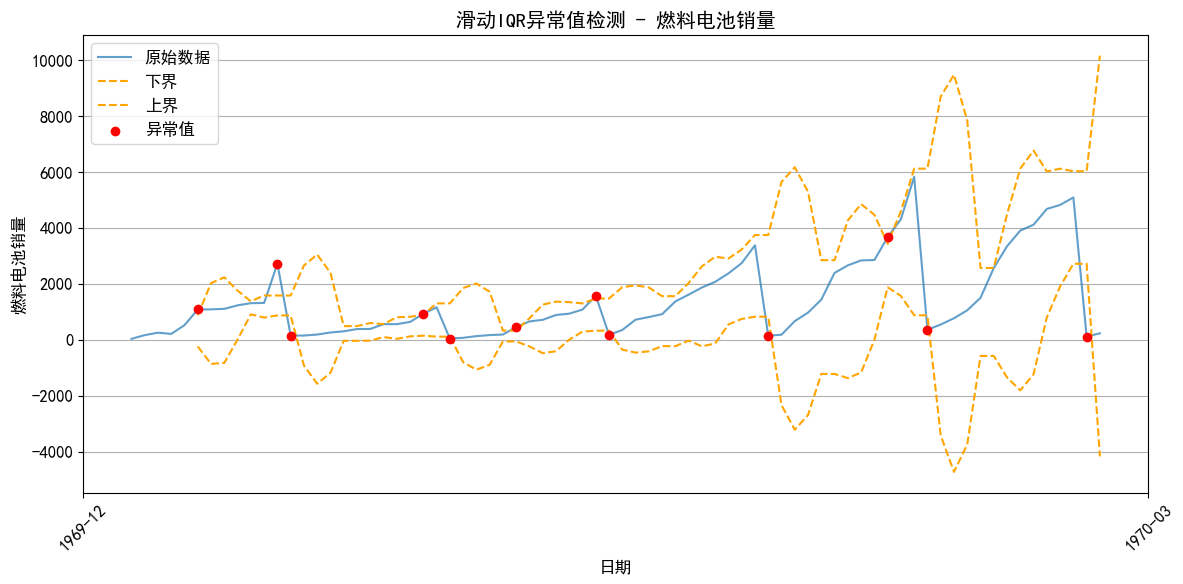

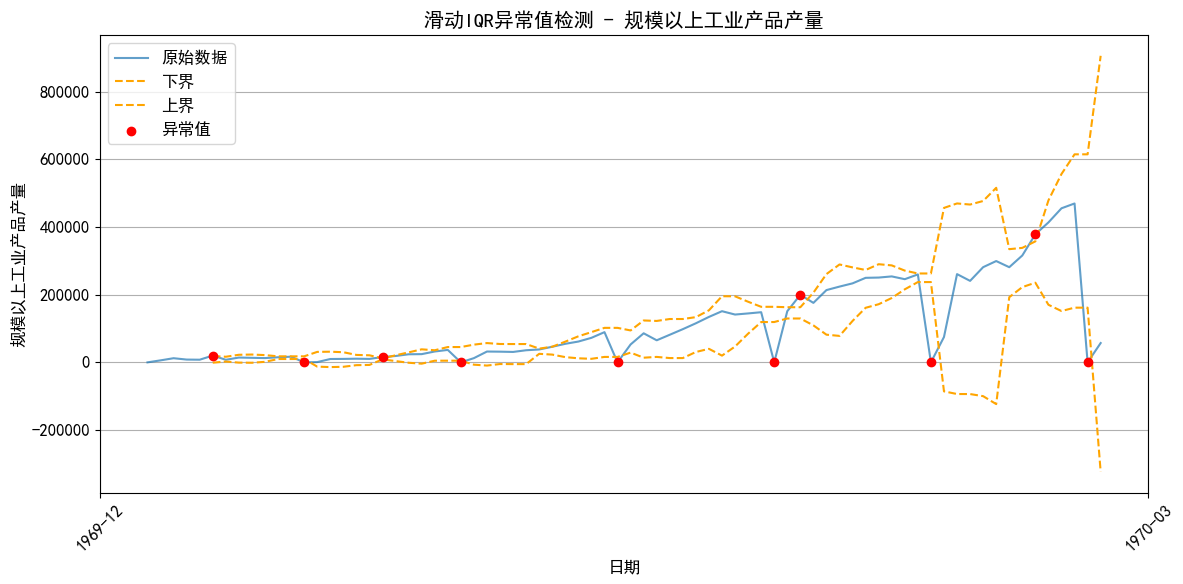

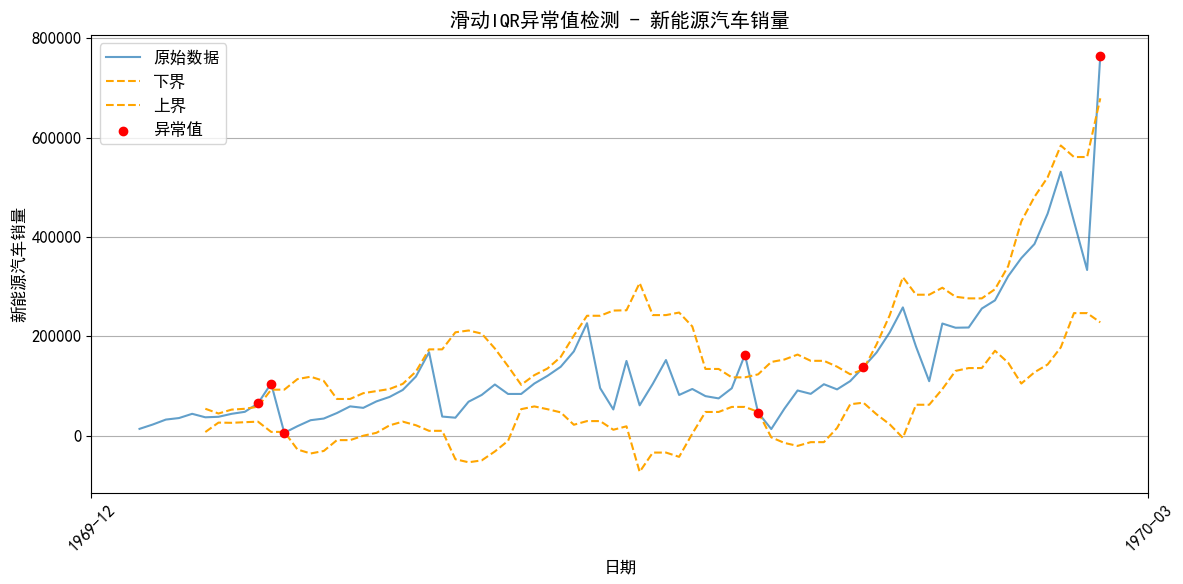

所有变量中共有 64 个异常值


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

df = pd.read_excel('数据描述量.xlsx', header=0)  # 请确保文件路径正确

df.set_index('结束日期', inplace=True)

def rolling_iqr(df, column_name, window_size=6):
    # 计算滑动窗口的四分位数
    rolling_q1 = df[column_name].rolling(window=window_size).quantile(0.25)
    rolling_q3 = df[column_name].rolling(window=window_size).quantile(0.75)
    rolling_iqr = rolling_q3 - rolling_q1

    # 计算异常值的上下界
    lower_bound = rolling_q1 - 1.5 * rolling_iqr
    upper_bound = rolling_q3 + 1.5 * rolling_iqr

    # 标记异常值
    outliers = (df[column_name] < lower_bound) | (df[column_name] > upper_bound)

    # 创建结果DataFrame
    result = pd.DataFrame({
        'value': df[column_name],
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'is_outlier': outliers
    })

    return result

# 初始化总异常值计数
total_outliers = 0

# 遍历所有列，应用滑动四分位间距法
for column in df.columns:
    result = rolling_iqr(df, column)
    # 计算异常值的数量
    outlier_count = result['is_outlier'].sum()
    total_outliers += outlier_count
    
    # 异常值可视化
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column], label='原始数据', alpha=0.7)
    plt.plot(df.index, result['lower_bound'], label='下界', linestyle='--', color='orange')
    plt.plot(df.index, result['upper_bound'], label='上界', linestyle='--', color='orange')
    plt.scatter(df.index[result['is_outlier']], df[column][result['is_outlier']], 
                color='red', label='异常值', zorder=5)
    
    # 设置x轴刻度为6个月为单位
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    plt.title(f'滑动IQR异常值检测 - {column}')
    plt.xlabel('日期')
    plt.ylabel(column)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)  # 旋转x轴刻度标签，以便更好地显示
    
    plt.tight_layout()
    plt.show()

# 输出总异常值数量
print(f'所有变量中共有 {total_outliers} 个异常值')

数据框列名： ['公共充电桩数量', '公共充电桩充电电量', '电池装机量', '燃料电池产量', '新能源汽车产量', '燃料电池销量', '规模以上工业产品产量', '新能源汽车销量']


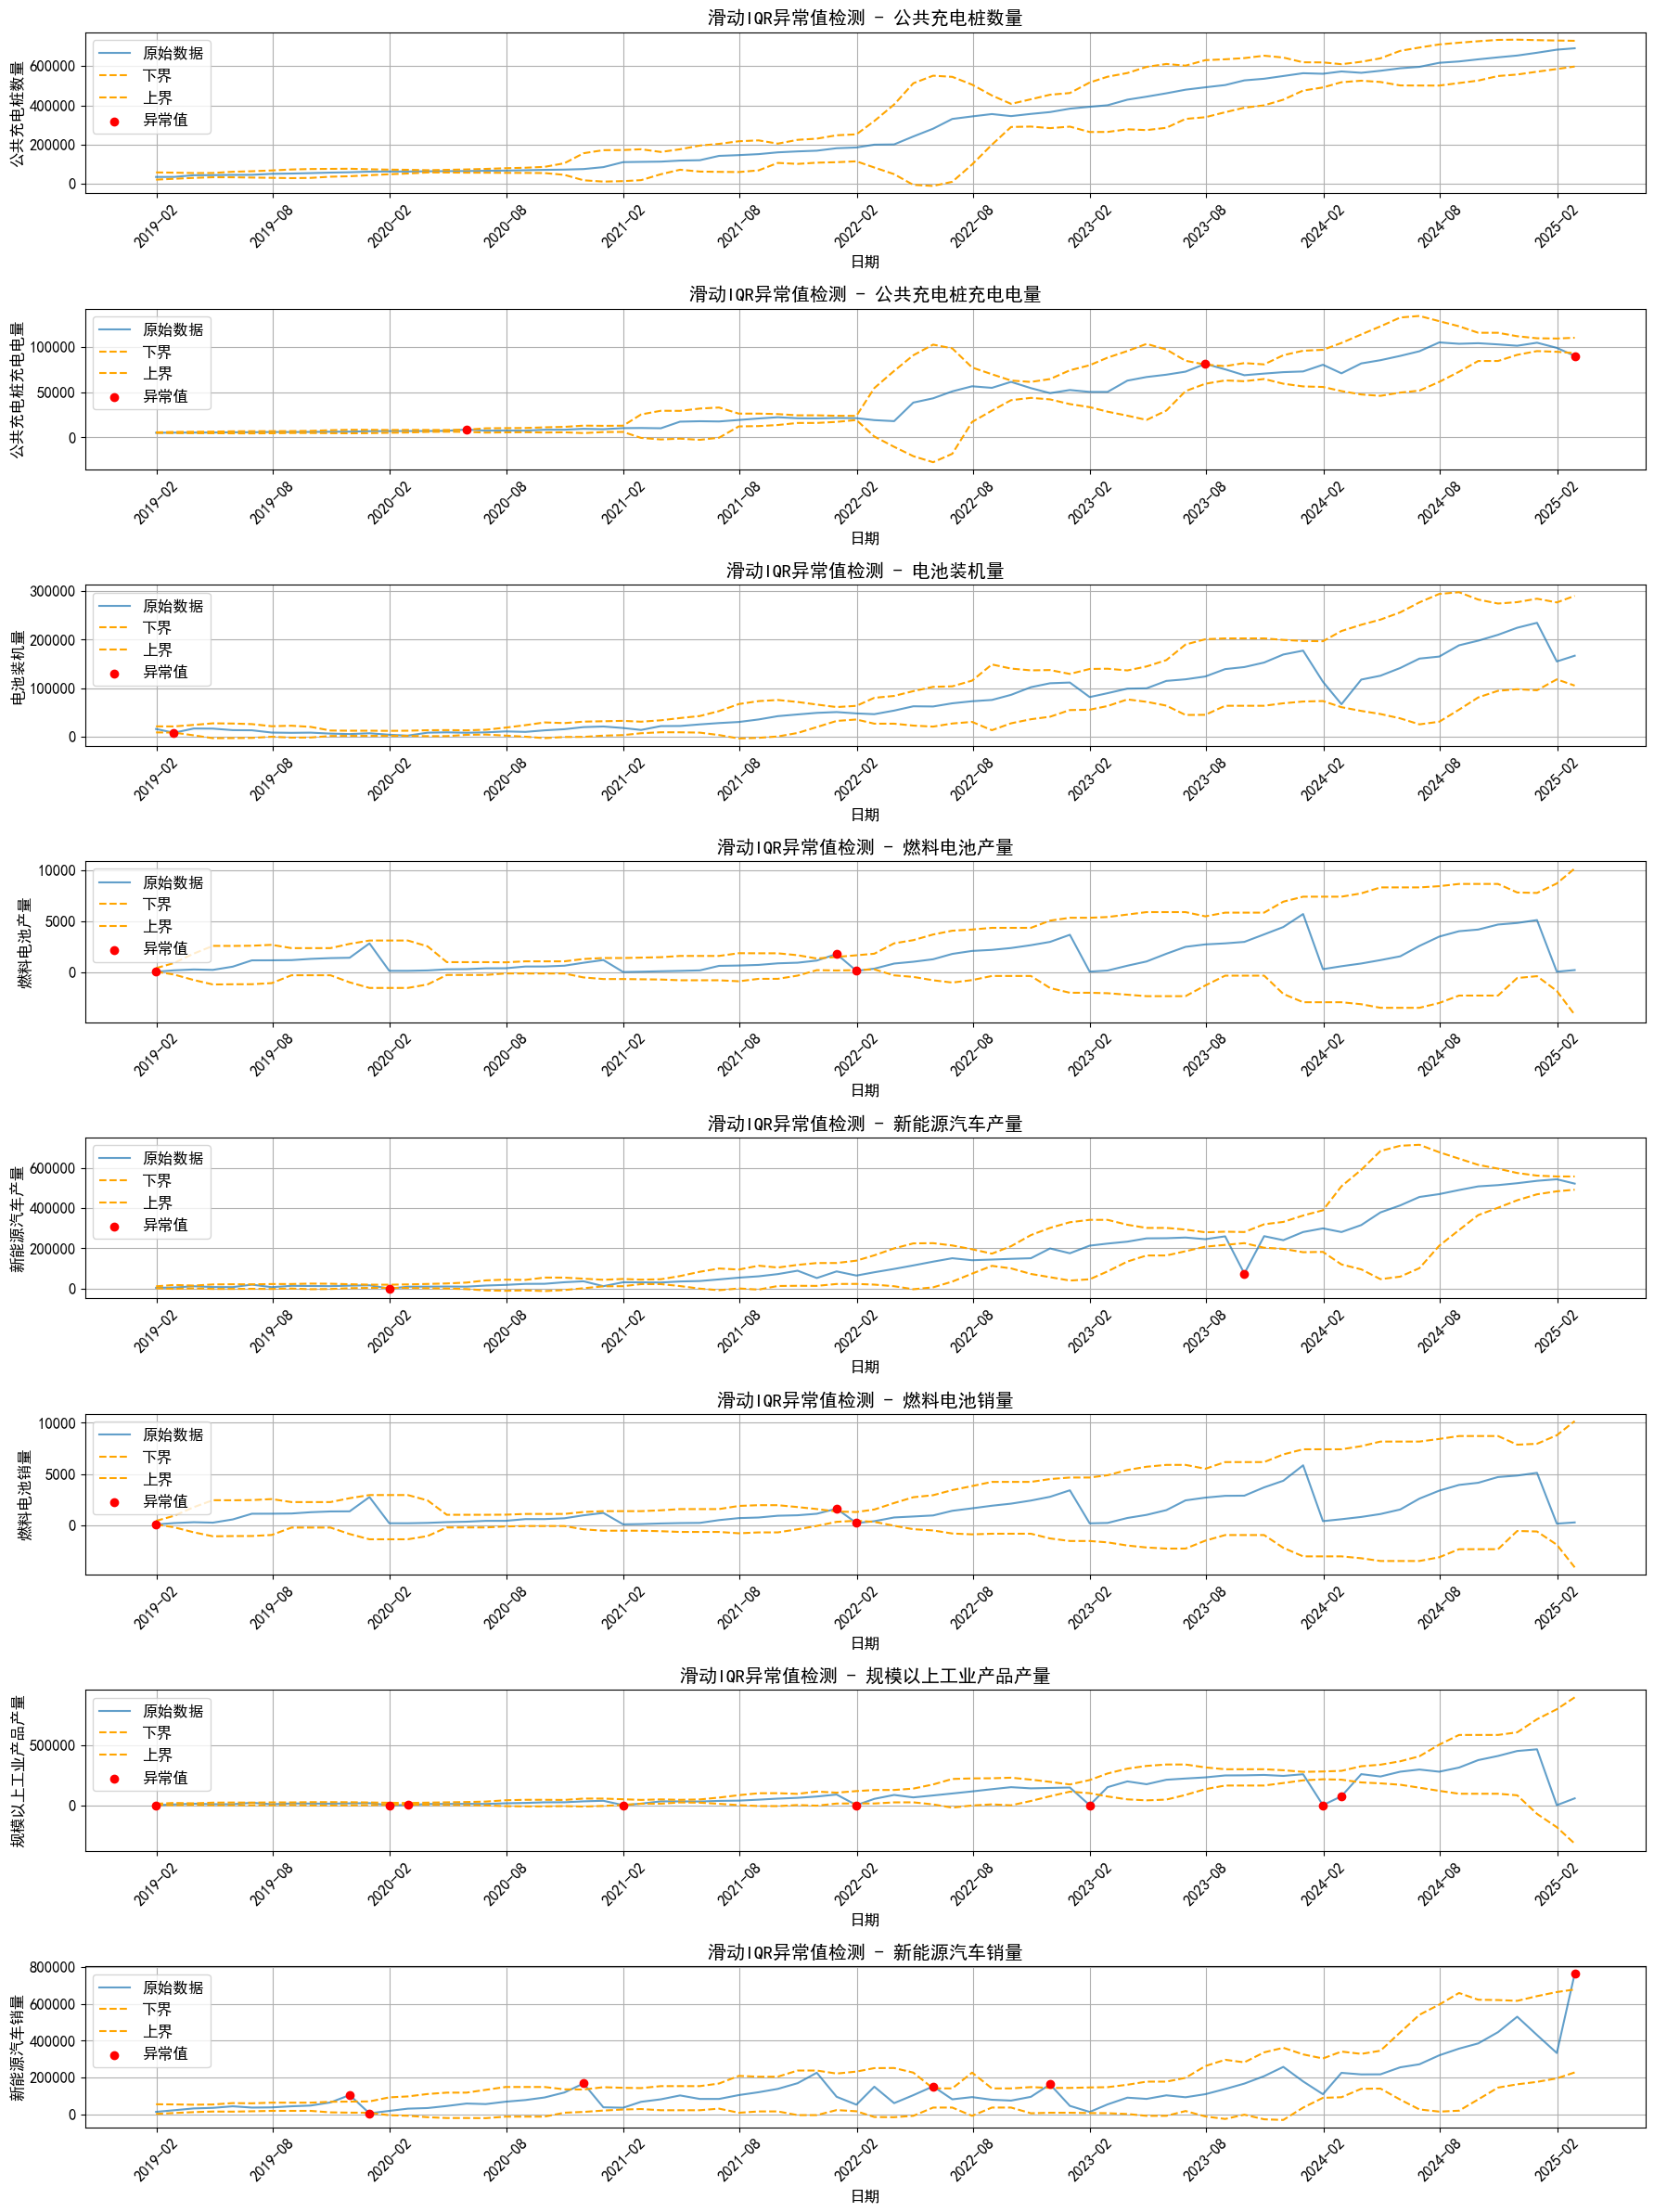

列 '公共充电桩数量' 的异常值数量: 0
列 '公共充电桩充电电量' 的异常值数量: 3
列 '电池装机量' 的异常值数量: 1
列 '燃料电池产量' 的异常值数量: 3
列 '新能源汽车产量' 的异常值数量: 2
列 '燃料电池销量' 的异常值数量: 3
列 '规模以上工业产品产量' 的异常值数量: 8
列 '新能源汽车销量' 的异常值数量: 6


<Figure size 640x480 with 0 Axes>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

df = pd.read_excel("数据描述量.xlsx")

start_date = datetime(2019, 1, 1)
end_date = datetime(2025, 2, 28)
date_range = pd.date_range(start=start_date, end=end_date, freq='ME')  # 使用 'ME' 替代 'M'
df.index = date_range

print("数据框列名：", df.columns.tolist())

def sliding_iqr(df, column_name, window_size=10, threshold=1.5):
    result = pd.DataFrame(index=df.index)
    result['value'] = df[column_name]
    
    lower_bound = []
    upper_bound = []
    is_outlier = []
    
    for i in range(len(df)):
        # 确定滑动窗口范围
        start = max(0, i - window_size // 2)
        end = min(len(df), i + window_size // 2)
        window = df[column_name].iloc[start:end]
        
        # 计算四分位数和IQR
        q1 = window.quantile(0.25)
        q3 = window.quantile(0.75)
        iqr = q3 - q1
        
        # 计算上下界
        lb = q1 - threshold * iqr
        ub = q3 + threshold * iqr
        
        # 检测异常值
        outlier = df[column_name].iloc[i] < lb or df[column_name].iloc[i] > ub
        
        lower_bound.append(lb)
        upper_bound.append(ub)
        is_outlier.append(outlier)
    
    result['lower_bound'] = lower_bound
    result['upper_bound'] = upper_bound
    result['is_outlier'] = is_outlier
    return result

# 检测并可视化所有指标的异常值
plt.figure(figsize=(18, 24))  # 调整图表大小
columns = df.columns.tolist()

for i, column_name in enumerate(columns):
    result = sliding_iqr(df, column_name)
    
    plt.subplot(len(columns), 1, i + 1)
    plt.plot(df.index, df[column_name], label='原始数据', alpha=0.7)
    plt.plot(df.index, result['lower_bound'], label='下界', linestyle='--', color='orange')
    plt.plot(df.index, result['upper_bound'], label='上界', linestyle='--', color='orange')
    plt.scatter(df.index[result['is_outlier']], df[column_name][result['is_outlier']], 
                color='red', label='异常值', zorder=5)
    plt.title(f'滑动IQR异常值检测 - {column_name}')
    plt.xlabel('日期')
    plt.ylabel(column_name)
    plt.legend()
    plt.grid(True)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

for column_name in columns:
    result = sliding_iqr(df, column_name)
    print(f"列 '{column_name}' 的异常值数量: {result['is_outlier'].sum()}")
    plt.rcParams['font.size'] = 12 
plt.savefig('anomaly_detection.png', dpi=300) 